<a href="https://colab.research.google.com/github/GayatriVidhate23/Machine--Vision-Practical/blob/main/Pr07_MV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving road_trafifc.mp4 to road_trafifc.mp4


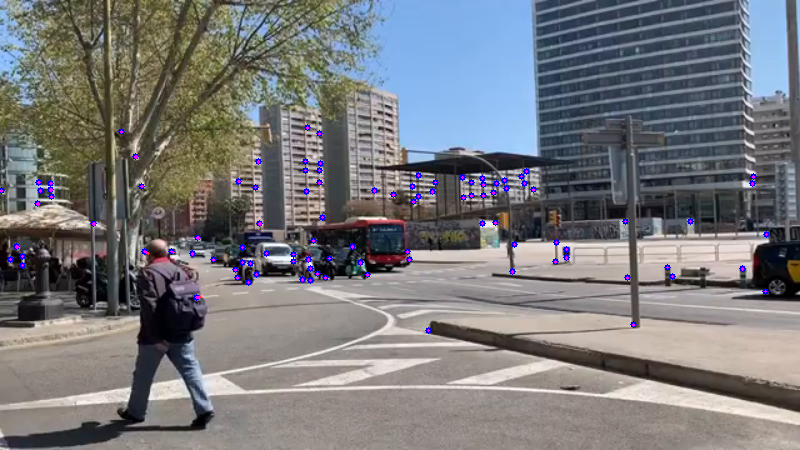

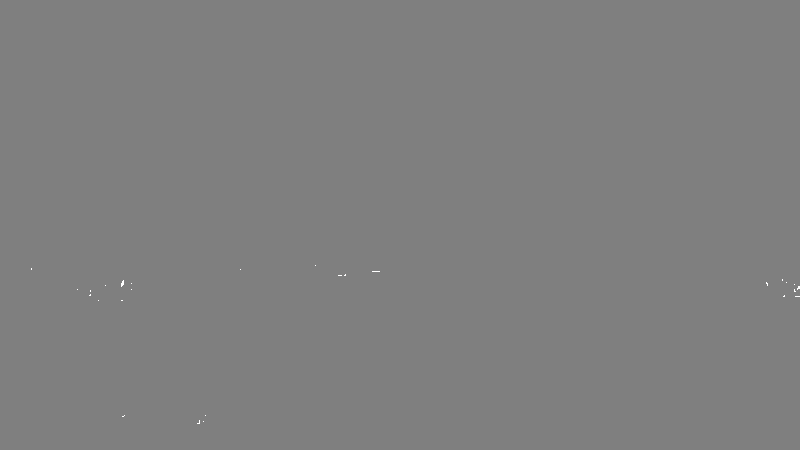

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

video = list(uploaded.keys())[0]
cap = cv2.VideoCapture(video)

fgbg = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50)

ret, old = cap.read()
old = cv2.resize(old, (800,450))
old_gray = cv2.cvtColor(old, cv2.COLOR_BGR2GRAY)

p0 = cv2.goodFeaturesToTrack(old_gray,
                             maxCorners=100,
                             qualityLevel=0.3,
                             minDistance=7,
                             blockSize=7)

mask = np.zeros_like(old)

while True:

    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame,(800,450))

    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)

    # Background Subtraction
    fgmask = fgbg.apply(frame)

    # Motion Detection
    _,th = cv2.threshold(fgmask,200,255,cv2.THRESH_BINARY)
    contours,_ = cv2.findContours(th,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    for c in contours:
        if cv2.contourArea(c)>500:
            x,y,w,h=cv2.boundingRect(c)
            cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)

    # Optical Flow
    if p0 is not None:
        p1,st,err=cv2.calcOpticalFlowPyrLK(old_gray,gray,p0,None)

        if p1 is not None:
            good_new=p1[st==1]
            good_old=p0[st==1]

            for new,oldp in zip(good_new,good_old):
                a,b=new.ravel().astype(int)
                c,d=oldp.ravel().astype(int)

                cv2.line(mask,(a,b),(c,d),(0,0,255),2)
                cv2.circle(frame,(a,b),3,(255,0,0),-1)

            output=cv2.add(frame,mask)

            old_gray=gray.copy()
            p0=good_new.reshape(-1,1,2)

    cv2_imshow(output)
    cv2_imshow(fgmask)

cap.release()